# FX portfolio risk: what the dashboard calculates

This notebook repeats every number on the dashboard one step at a time. Each step is done twice:

1. **by hand**, in plain NumPy and pandas, so you can see the formula;
2. **with the dashboard's own function** from `fxrisk/`, the code `app.py` calls.

`check()` then confirms the two agree. If you change a formula in `fxrisk/risk.py`, the matching check here will fail.

The steps follow the order the dashboard works in: read the trades, get prices, value the trades, map them to currency exposures, simulate P&L, then VaR and its breakdown, limit usage, hedges and the backtest.

## 0. Settings
Point `PORTFOLIO` at any CSV: the sample book, or a file in `tests/portfolios/` such as `single_trade.csv` or `fully_hedged.csv`.

In [1]:
PORTFOLIO = "../data/portfolio.csv"   # e.g. "../tests/portfolios/single_trade.csv"
SOURCE    = "auto"   # "auto" = Yahoo Finance like the dashboard; "snapshot" = bundled prices (reproducible)
CONF      = 0.99     # VaR confidence
HORIZON   = 1        # days
WINDOW    = 500      # look-back, in daily returns
LAMBDA    = 0.94     # EWMA decay
LIMIT     = 1_000_000

In [2]:
import sys, math
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # make the fxrisk package importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2

from fxrisk import risk as rk
from fxrisk.market import load_market, load_snapshot
from fxrisk.portfolio import load_portfolio, check_against_market

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 160)

def check(name, manual, engine, rtol=1e-9, atol=1e-6):
    """Assert the hand calculation matches the dashboard's function."""
    ok = np.allclose(np.asarray(manual, float), np.asarray(engine, float), rtol=rtol, atol=atol, equal_nan=True)
    print(f"{'✓' if ok else '✗'} {name}")
    assert ok, f"{name}: manual {manual} vs engine {engine}"

## 1. Read the portfolio
The raw file first, then the cleaned table. `load_portfolio` normalises formats (e.g. `EUR/USD` becomes `EURUSD`, `"1,000,000"` becomes `1000000`) and rejects bad rows with a reason. It never raises on bad input. Each accepted trade gets:
- `base` and `quote`: the two currencies of the pair;
- `N`, the signed base-currency notional: + for BUY, − for SELL.

In [3]:
print(Path(PORTFOLIO).read_text()[:1500])

trade_id,trade_date,currency_pair,side,notional,entry_price,book
T001,2026-03-16,EURUSD,BUY,25000000,1.14303,Macro
T002,2026-04-21,USDJPY,SELL,20000000,158.711,Macro
T003,2026-05-11,GBPUSD,SELL,15000000,1.35996,Relative Value
T004,2026-06-02,AUDUSD,BUY,20000000,0.71569,Commodity FX
T005,2026-06-18,USDCAD,BUY,18000000,1.41010,Commodity FX
T006,2026-07-07,EURGBP,BUY,12000000,0.85372,Relative Value
T007,2026-07-22,USDMXN,SELL,10000000,17.3849,EM Carry
T008,2026-08-12,AUDNZD,BUY,15000000,1.20138,Relative Value
T009,2026-08-27,USDCHF,BUY,12000000,0.80416,Macro
T010,2026-09-03,EURUSD,BUY,10000000,1.15835,Macro
T011,2026-09-09,EURNOK,SELL,8000000,10.7051,Relative Value
T012,2026-09-17,USDZAR,SELL,6000000,16.3603,EM Carry
T013,2026-09-24,USDSEK,BUY,10000000,9.9133,Relative Value
T014,2026-09-29,EURUSD,SELL,5000000,1.13816,Macro
T015,2026-10-01,EURJPY,BUY,10000000,178.308,Macro
T016,2026-10-02,USDSGD,SELL,15000000,1.27915,EM Carry



In [4]:
SRC = (load_snapshot(), []) if SOURCE == "snapshot" else load_market(SOURCE)
mkt, fallbacks = SRC
book, errors = load_portfolio(PORTFOLIO, mkt.currencies)
book, mkt_errors, warnings = check_against_market(book, mkt)   # future dates, inverted/mistyped prices
for e in errors + mkt_errors: print("REJECTED:", e)
for w in warnings: print("WARNING:", w)
print(f"{len(book)} trades accepted")
book

ZAR: removed bad prints on ['2024-11-15', '2025-01-15', '2025-01-17']


16 trades accepted


,trade_id,trade_date,currency_pair,side,notional,entry_price,book,base,quote,N
0,T001,2026-03-16,EURUSD,BUY,25000000,1.14,Macro,EUR,USD,"25,000,000.00"
1,T002,2026-04-21,USDJPY,SELL,20000000,158.71,Macro,USD,JPY,"-20,000,000.00"
2,T003,2026-05-11,GBPUSD,SELL,15000000,1.36,Relative Value,GBP,USD,"-15,000,000.00"
3,T004,2026-06-02,AUDUSD,BUY,20000000,0.72,Commodity FX,AUD,USD,"20,000,000.00"
4,T005,2026-06-18,USDCAD,BUY,18000000,1.41,Commodity FX,USD,CAD,"18,000,000.00"
5,T006,2026-07-07,EURGBP,BUY,12000000,0.85,Relative Value,EUR,GBP,"12,000,000.00"
6,T007,2026-07-22,USDMXN,SELL,10000000,17.38,EM Carry,USD,MXN,"-10,000,000.00"
7,T008,2026-08-12,AUDNZD,BUY,15000000,1.20,Relative Value,AUD,NZD,"15,000,000.00"
8,T009,2026-08-27,USDCHF,BUY,12000000,0.80,Macro,USD,CHF,"12,000,000.00"
9,T010,2026-09-03,EURUSD,BUY,10000000,1.16,Macro,EUR,USD,"10,000,000.00"


## 2. Market data
The dashboard uses Yahoo Finance. It falls back to ECB fixings, then to the bundled snapshot, only if Yahoo fails.

Every rate is held as **u(c) = USD per 1 unit of currency c**, with u(USD) = 1. That one convention prices any pair:

$$S_{BASE/QUOTE} = \frac{u(BASE)}{u(QUOTE)}$$

so EURGBP is triangulated from the same EUR and GBP rates that drive the risk.

In [5]:
print("Source      :", mkt.source)
print("Fallbacks   :", fallbacks or "none (primary source worked)")
print("Live quote  :", mkt.live_time)
print("Prev. close :", mkt.prev_date, " (reference for 'P&L today')")
print("History     :", len(mkt.hist), "daily closes from", mkt.hist.index[0])
pd.DataFrame({"USD per unit (live)": mkt.live.drop("USD"), "USD per unit (prev close)": mkt.prev.drop("USD")})

Source      : Yahoo Finance (daily closes; live = latest intraday quote)
Fallbacks   : none (primary source worked)
Live quote  : 2026-10-02 20:59:44+00:00
Prev. close : 2026-10-01  (reference for 'P&L today')
History     : 779 daily closes from 2023-10-02


,USD per unit (live),USD per unit (prev close)
EUR,1.13,1.13
GBP,1.32,1.33
JPY,0.01,0.01
AUD,0.70,0.69
CAD,0.70,0.70
CHF,1.21,1.20
NZD,0.56,0.56
NOK,0.10,0.10
SEK,0.10,0.10
MXN,0.06,0.06


In [6]:
# Triangulation by hand vs the engine, for every pair in the book
for pair in sorted(book.currency_pair.unique()):
    b, q = pair[:3], pair[3:]
    print(f"{pair}: u({b})/u({q}) = {mkt.live[b]:.6f}/{mkt.live[q]:.6f} = {mkt.live[b] / mkt.live[q]:.5f}")
    check(f"  {pair} price", mkt.live[b] / mkt.live[q], mkt.spot(pair))

AUDNZD: u(AUD)/u(NZD) = 0.695700/0.562300 = 1.23724
✓   AUDNZD price
AUDUSD: u(AUD)/u(USD) = 0.695700/1.000000 = 0.69570
✓   AUDUSD price
EURGBP: u(EUR)/u(GBP) = 1.125700/1.324000 = 0.85023
✓   EURGBP price
EURJPY: u(EUR)/u(JPY) = 1.125700/0.006336 = 177.66923
✓   EURJPY price
EURNOK: u(EUR)/u(NOK) = 1.125700/0.104075 = 10.81629
✓   EURNOK price
EURUSD: u(EUR)/u(USD) = 1.125700/1.000000 = 1.12570
✓   EURUSD price
GBPUSD: u(GBP)/u(USD) = 1.324000/1.000000 = 1.32400
✓   GBPUSD price
USDCAD: u(USD)/u(CAD) = 1.000000/0.702001 = 1.42450
✓   USDCAD price
USDCHF: u(USD)/u(CHF) = 1.000000/1.207001 = 0.82850
✓   USDCHF price
USDJPY: u(USD)/u(JPY) = 1.000000/0.006336 = 157.83000
✓   USDJPY price
USDMXN: u(USD)/u(MXN) = 1.000000/0.055112 = 18.14500
✓   USDMXN price
USDSEK: u(USD)/u(SEK) = 1.000000/0.099578 = 10.04240
✓   USDSEK price
USDSGD: u(USD)/u(SGD) = 1.000000/0.781922 = 1.27890
✓   USDSGD price
USDZAR: u(USD)/u(ZAR) = 1.000000/0.060088 = 16.64230
✓   USDZAR price


## 3. Valuation and P&L
A spot trade is two cash amounts: **+N of BASE** and **−N·K of QUOTE**, where K is the entry price. Its value in USD is

$$V = N\,u(BASE) - N K\,u(QUOTE) \;=\; N\,(S-K)\,u(QUOTE)$$

- **P&L since inception** is V at live rates.
- **P&L today** is V(live) − V(previous close). A trade booked after the previous close has no earlier value, so all of its P&L counts as today's.

In [7]:
def usd_value(tr, u):
    return tr.N * u[tr.base] - tr.N * tr.entry_price * u[tr.quote]

manual = pd.DataFrame(index=book.trade_id)
manual["pair"] = book.currency_pair.values
manual["spot"] = [mkt.live[t.base] / mkt.live[t.quote] for t in book.itertuples()]
manual["pnl_itd"] = [usd_value(t, mkt.live) for t in book.itertuples()]
opened_today = (book.trade_date > mkt.prev_date).values
manual["pnl_day"] = np.where(opened_today, manual.pnl_itd,
                             manual.pnl_itd - [usd_value(t, mkt.prev) for t in book.itertuples()])

pos, X = rk.value_positions(book, mkt)        # <- what the dashboard calls
check("spot per trade", manual.spot, pos.spot)
check("P&L since inception per trade", manual.pnl_itd, pos.pnl_itd)
check("P&L today per trade", manual.pnl_day, pos.pnl_day)
print(f"\nBook P&L since inception: {manual.pnl_itd.sum():,.0f}   today: {manual.pnl_day.sum():,.0f}")
manual

✓ spot per trade
✓ P&L since inception per trade
✓ P&L today per trade

Book P&L since inception: -186,886   today: -354,692


,pair,spot,pnl_itd,pnl_day
trade_id,,,,
T001,EURUSD,1.13,"-433,250.00","-175,520.70"
T002,USDJPY,157.83,"111,639.11","-34,719.87"
T003,GBPUSD,1.32,"539,400.00","36,538.85"
T004,AUDUSD,0.70,"-399,800.00","22,602.29"
T005,USDCAD,1.42,"181,958.58","11,639.84"
T006,EURGBP,0.85,"-55,503.36","-59,294.78"
T007,USDMXN,18.14,"-418,903.28","-35,934.71"
T008,AUDNZD,1.24,"302,460.39","38,192.86"
T009,USDCHF,0.83,"352,540.74","-99,796.07"


In [8]:
# One trade in full, so every number can be followed
t = book.iloc[0]
S = mkt.live[t.base] / mkt.live[t.quote]
print(f"{t.trade_id}: {t.side} {t.notional:,.0f} {t.base} vs {t.quote} at {t.entry_price}")
print(f"  live price S = {S:.5f}; move = S - K = {S - t.entry_price:+.5f} {t.quote} per {t.base}")
print(f"  P&L in {t.quote} = N*(S-K) = {t.N:,.0f} * {S - t.entry_price:+.5f} = {t.N * (S - t.entry_price):,.0f}")
print(f"  converted to USD at u({t.quote}) = {mkt.live[t.quote]:.6f}: {t.N * (S - t.entry_price) * mkt.live[t.quote]:,.0f} USD")

T001: BUY 25,000,000 EUR vs USD at 1.14303
  live price S = 1.12570; move = S - K = -0.01733 USD per EUR
  P&L in USD = N*(S-K) = 25,000,000 * -0.01733 = -433,250
  converted to USD at u(USD) = 1.000000: -433,250 USD


## 4. Currency exposures
To measure risk, each trade is split into USD-equivalent exposures:

$$x(BASE) = N\,u(BASE), \qquad x(QUOTE) = -N K\,u(QUOTE)$$

The USD leg is dropped because it carries no FX risk for a USD book. Exposures **net across trades**: EURUSD, EURGBP and EURJPY all add to one EUR number. The dashboard's *Net currency exposure* chart shows these totals.

In [9]:
X_manual = pd.DataFrame(0.0, index=book.trade_id, columns=mkt.currencies)
for t in book.itertuples():
    if t.base != "USD":  X_manual.loc[t.trade_id, t.base]  += t.N * mkt.live[t.base]
    if t.quote != "USD": X_manual.loc[t.trade_id, t.quote] -= t.N * t.entry_price * mkt.live[t.quote]

check("exposure matrix (trade x currency)", X_manual, X)
e = X_manual.sum()                       # net exposure per currency
print("\nNet USD exposure by currency:")
print((e / 1e6).round(2).to_string(), "\n(USD mm; implied USD cash leg =", round(-e.sum() / 1e6, 2), "mm)")
X_manual.loc[:, (X_manual != 0).any()].round(0)

✓ exposure matrix (trade x currency)

Net USD exposure by currency:
EUR    49.53
GBP   -33.42
JPY     8.81
AUD    24.35
CAD   -17.82
CHF   -11.65
NZD   -10.13
NOK     8.91
SEK    -9.87
MXN     9.58
ZAR     5.90
SGD    15.00 
(USD mm; implied USD cash leg = -39.2 mm)


,EUR,GBP,JPY,AUD,CAD,CHF,NZD,NOK,SEK,MXN,ZAR,SGD
trade_id,,,,,,,,,,,,
T001,"28,142,500.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
T002,0.00,0.00,"20,111,639.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
T003,0.00,"-19,860,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
T004,0.00,0.00,0.00,"13,914,000.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
T005,0.00,0.00,0.00,0.00,"-17,818,041.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
T006,"13,508,400.00","-13,563,903.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
T007,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"9,581,097.00",0.00,0.00
T008,0.00,0.00,0.00,"10,435,500.00",0.00,0.00,"-10,133,040.00",0.00,0.00,0.00,0.00,0.00
T009,0.00,0.00,0.00,0.00,0.00,"-11,647,459.00",0.00,0.00,0.00,0.00,0.00,0.00


## 5. Risk factors: historical daily returns
The risk factors are the simple daily returns of each u(c). Row *t* holds the moves of all 12 currencies against USD on day *t*. VaR uses the last `WINDOW` rows.

In [10]:
R_all = mkt.hist.pct_change().iloc[1:]
check("returns matrix", R_all, mkt.returns)
R = R_all.iloc[-WINDOW:]
print(f"{len(R)} scenarios: {R.index[0]} → {R.index[-1]}")
print("\nAnnualised volatility over the window:")
print((R.std() * np.sqrt(252)).map("{:.1%}".format).to_string())

✓ returns matrix
500 scenarios: 2024-10-25 → 2026-10-01

Annualised volatility over the window:
EUR     7.2%
GBP     7.1%
JPY     9.2%
AUD     9.6%
CAD     5.4%
CHF     8.3%
NZD     9.6%
NOK     9.4%
SEK    10.1%
MXN     9.8%
ZAR    11.6%
SGD     4.7%


## 6. Scenario P&L: today's book over each historical day
Apply each historical day's moves to today's exposures:

$$P_t = \sum_c x(c)\, R_t(c) = R_t \cdot e$$

For spot this is an **exact** revaluation, not an approximation: V is linear in u. The cell below proves it by fully repricing every trade at shocked rates for one scenario.

In [11]:
P = R.values @ e.values                         # portfolio P&L in each scenario
Pi = R.values @ X_manual.values.T               # per-trade P&L, scenarios x trades

# Exactness check on the worst scenario: reprice every trade from scratch.
t_worst = P.argmin()
u_shocked = mkt.live.copy()
u_shocked[mkt.currencies] *= 1 + R.iloc[t_worst]
repriced = sum(usd_value(t, u_shocked) - usd_value(t, mkt.live) for t in book.itertuples())
print(f"Worst day {R.index[t_worst]}: exposures x returns = {P[t_worst]:,.2f}, full repricing = {repriced:,.2f}")
check("linear scenario P&L equals full repricing", P[t_worst], repriced)

Worst day 2025-04-07: exposures x returns = -1,281,697.94, full repricing = -1,281,697.94
✓ linear scenario P&L equals full repricing


## 7. Historical-simulation VaR and expected shortfall (the dashboard default)
Sort the scenario P&Ls. With *n* scenarios and confidence α, let **k = ⌈n(1−α)⌉**:
- **VaR** is the k-th worst loss;
- **ES** is the average of the k worst.

At 99% with 500 scenarios, k = 5. Multi-day horizons scale by √h.

In [12]:
n = len(P)
k = max(1, math.ceil(n * (1 - CONF) - 1e-9))  # the -1e-9 avoids 500*(1-0.99)=5.000000000000004 -> 6
order = np.argsort(P, kind="stable")
var_hs = -P[order[k - 1]] * math.sqrt(HORIZON)
es_hs = -P[order[:k]].mean() * math.sqrt(HORIZON)

cfg = rk.RiskConfig("hs", CONF, HORIZON, WINDOW, LAMBDA)
rep = rk.risk_report(X, mkt.returns, cfg)       # <- what the dashboard calls
check("HS VaR", var_hs, rep["var"]); check("HS ES", es_hs, rep["es"])
print(f"\nk = {k}.  {CONF:.0%} {HORIZON}-day HS VaR = {var_hs:,.0f}   ES = {es_hs:,.0f}")
print("\nThe k worst days for today's book (VaR is the last one listed):")
pd.DataFrame({"date": R.index[order[:k]], "P&L": P[order[:k]]})

✓ HS VaR
✓ HS ES

k = 5.  99% 1-day HS VaR = 662,157   ES = 828,405

The k worst days for today's book (VaR is the last one listed):


,date,P&L
0,2025-04-07,"-1,281,697.94"
1,2024-11-07,"-778,179.21"
2,2025-02-03,"-733,240.02"
3,2026-03-04,"-686,752.88"
4,2024-11-11,"-662,156.96"


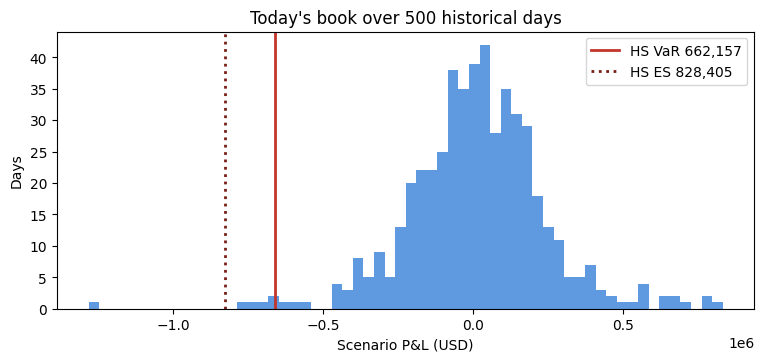

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(P, bins=60, color="#2a78d6", alpha=.75)
ax.axvline(-var_hs, color="#c2362b", lw=2, label=f"HS VaR {var_hs:,.0f}")
ax.axvline(-es_hs, color="#7a1f17", lw=2, ls=":", label=f"HS ES {es_hs:,.0f}")
ax.set(xlabel="Scenario P&L (USD)", ylabel="Days", title=f"Today's book over {n} historical days")
ax.legend(); plt.show()

## 8. Parametric VaR (normal, and EWMA)
Assume P&L is normal with mean zero. Using the covariance Σ of the factor returns:

$$\sigma_p = \sqrt{e^\top \Sigma\, e}, \qquad \text{VaR} = z_\alpha \sigma_p \sqrt{h}, \qquad \text{ES} = \sigma_p \frac{\varphi(z_\alpha)}{1-\alpha}\sqrt{h}$$

- **Equal-weight Σ:** every day counts the same: Σ = RᵀR / n (zero mean).
- **EWMA Σ:** day *t* gets weight ∝ λ^(age), so recent volatility dominates.

In [14]:
z = norm.ppf(CONF)
S_eq = R.values.T @ R.values / n
w = LAMBDA ** np.arange(n - 1, -1, -1); w /= w.sum()
S_ew = (R.values * w[:, None]).T @ R.values

for name, S, method in [("normal", S_eq, "normal"), ("EWMA", S_ew, "ewma")]:
    sigma = math.sqrt(e.values @ S @ e.values)
    var_p = z * sigma * math.sqrt(HORIZON)
    es_p = sigma * norm.pdf(z) / (1 - CONF) * math.sqrt(HORIZON)
    r = rk.risk_report(X, mkt.returns, rk.RiskConfig(method, CONF, HORIZON, WINDOW, LAMBDA))
    check(f"{name} covariance", S, r["S"]); check(f"{name} VaR", var_p, r["var"]); check(f"{name} ES", es_p, r["es"])
    print(f"   {name:6s}: daily σ = {sigma:,.0f}, z = {z:.4f}, VaR = {var_p:,.0f}, ES = {es_p:,.0f}\n")
print(f"HS VaR / normal VaR = {var_hs / (z * math.sqrt(e.values @ S_eq @ e.values) * math.sqrt(HORIZON)):.2f}"
      "  (above 1 means fat tails: the worst days are worse than a normal distribution predicts)")

✓ normal covariance
✓ normal VaR
✓ normal ES
   normal: daily σ = 230,822, z = 2.3263, VaR = 536,971, ES = 615,189



✓ EWMA covariance
✓ EWMA VaR
✓ EWMA ES
   EWMA  : daily σ = 171,729, z = 2.3263, VaR = 399,502, ES = 457,695

HS VaR / normal VaR = 1.23  (above 1 means fat tails: the worst days are worse than a normal distribution predicts)


## 9. Breaking VaR down by trade
The *Risk decomposition* tab shows these columns:

| Measure | Formula | Meaning |
|---|---|---|
| Standalone VaR | VaR of the trade alone | Risk ignoring the rest of the book |
| Component VaR | parametric: z·xᵢᵀΣe/σ_p; HS: see below | Share of portfolio VaR. Components **sum to VaR**. |
| Marginal VaR | component ÷ USD notional × 1mm | Extra VaR from +$1mm more of the trade |
| Incremental VaR | VaR(book) − VaR(book without trade) | Exact effect of closing the trade |
| Component ES | mean trade P&L over the k worst days | Share of ES. Sums exactly to HS ES. |

**HS component VaR** comes from a single sorted scenario, which is too noisy to use directly. The dashboard averages each trade's P&L over the scenarios ranked k−m … k+m (m = ⌊k/2⌋), then rescales so the components add up to VaR.

In [15]:
s = math.sqrt(HORIZON)
def hs(p):                                  # (VaR, ES) of a P&L vector
    o = np.sort(p); return -o[k - 1] * s, -o[:k].mean() * s

m_band = max(1, k // 2)
band = order[max(0, k - 1 - m_band): k + m_band]
comp_hs = Pi[band].mean(axis=0) / P[band].mean() * var_hs if abs(P[band].mean()) > 1e-9 else np.zeros(len(book))

dec = pd.DataFrame(index=book.trade_id)
dec["pair"] = book.currency_pair.values
dec["standalone"] = [hs(Pi[:, i])[0] for i in range(len(book))]
dec["component"] = comp_hs
dec["pct_of_var"] = comp_hs / var_hs
usd_notional = (book.N.abs() * mkt.live[book.base].values).values
dec["marginal_per_mm"] = comp_hs / usd_notional * 1e6
dec["incremental"] = [var_hs - hs(P - Pi[:, i])[0] for i in range(len(book))]
dec["component_es"] = -Pi[order[:k]].mean(axis=0) * s

A = rk.analyse(pos, X, mkt, cfg)            # <- what the dashboard calls
for col in ["standalone", "component", "marginal_per_mm", "incremental", "component_es"]:
    check(f"HS {col}", dec[col], A["pos"]["items"][col])
check("components sum to VaR", dec.component.sum(), var_hs)
check("component ES sums to ES", dec.component_es.sum(), es_hs)
print(f"\nDiversification: sum of standalone VaRs {dec.standalone.sum():,.0f} vs portfolio VaR {var_hs:,.0f} "
      f"→ benefit {dec.standalone.sum() - var_hs:,.0f}")
dec.sort_values("component", ascending=False).round(0)

✓ HS standalone
✓ HS component
✓ HS marginal_per_mm
✓ HS incremental
✓ HS component_es
✓ components sum to VaR
✓ component ES sums to ES

Diversification: sum of standalone VaRs 2,715,111 vs portfolio VaR 662,157 → benefit 2,052,954


,pair,standalone,component,pct_of_var,marginal_per_mm,incremental,component_es
trade_id,,,,,,,
T001,EURUSD,"383,150.00","311,948.00",0.00,"11,085.00","253,033.00","297,530.00"
T004,AUDUSD,"173,257.00","172,264.00",0.00,"12,381.00","123,262.00","274,632.00"
T007,USDMXN,"163,683.00","158,171.00",0.00,"15,817.00","152,917.00","184,833.00"
T010,EURUSD,"153,260.00","124,779.00",0.00,"11,085.00","91,308.00","119,012.00"
T016,USDSGD,"114,869.00","103,533.00",0.00,"6,902.00","106,690.00","132,674.00"
T012,USDZAR,"145,131.00","101,444.00",0.00,"16,907.00","90,079.00","130,348.00"
T002,USDJPY,"330,163.00","83,727.00",0.00,"4,186.00","109,807.00","91,798.00"
T015,EURJPY,"160,922.00","77,747.00",0.00,"6,907.00","60,346.00","67,446.00"
T006,EURGBP,"87,487.00","50,864.00",0.00,"3,765.00","32,295.00","18,631.00"


In [16]:
# Parametric component VaR, and proof that marginal VaR really is a derivative:
# grow each trade by a tiny amount h and see how much portfolio VaR moves.
sigma = math.sqrt(e.values @ S_eq @ e.values)
comp_p = z * (X_manual.values @ S_eq @ e.values) / sigma * s if sigma > 0 else np.zeros(len(book))  # σ=0: fully hedged
rp = rk.risk_report(X, mkt.returns, rk.RiskConfig("normal", CONF, HORIZON, WINDOW))
check("parametric component VaR", comp_p, rp["items"].component)
check("parametric components sum to VaR", comp_p.sum(), rp["var"])

def var_normal(Xm): ev = Xm.sum(0); return z * math.sqrt(ev @ S_eq @ ev) * s
h = 1e-6
fd = []
for i in range(len(book)):
    up, dn = X_manual.values.copy(), X_manual.values.copy()
    up[i] *= 1 + h; dn[i] *= 1 - h
    fd.append((var_normal(up) - var_normal(dn)) / (2 * h))
check("component VaR = dVaR/d(size), finite difference", comp_p, fd, rtol=1e-5)

✓ parametric component VaR
✓ parametric components sum to VaR
✓ component VaR = dVaR/d(size), finite difference


## 10. The same VaR split by currency
This treats each currency's net exposure as one position. The currency view and the trade view add up to the same portfolio VaR.

In [17]:
ccy_items = pd.DataFrame(np.diag(e.values), index=e.index, columns=e.index)
Pc = R.values * e.values                       # P&L from each currency, scenarios x currencies
comp_ccy = Pc[band].mean(axis=0) / P[band].mean() * var_hs if abs(P[band].mean()) > 1e-9 else np.zeros(len(e))
check("currency component VaR", comp_ccy, A["ccy"]["items"].component)
check("currency components sum to the same VaR", comp_ccy.sum(), var_hs)
pd.DataFrame({"net exposure": e, "component VaR": comp_ccy, "% of VaR": comp_ccy / var_hs}).round(2)

✓ currency component VaR
✓ currency components sum to the same VaR


,net exposure,component VaR,% of VaR
EUR,"49,530,800.00","549,028.75",0.83
GBP,"-33,423,903.36","-243,635.40",-0.37
JPY,"8,814,167.14","36,694.26",0.06
AUD,"24,349,500.00","301,462.36",0.46
CAD,"-17,818,041.42","-108,957.90",-0.16
CHF,"-11,647,459.26","-77,781.08",-0.12
NZD,"-10,133,039.61","-126,272.25",-0.19
NOK,"8,913,024.93","94,268.53",0.14
SEK,"-9,871,445.07","-125,797.86",-0.19
MXN,"9,581,096.72","158,170.59",0.24


## 11. VaR limit usage
**Limit used = VaR on the limit's own measure ÷ limit.**

The limit is defined on one fixed measure (here 99%, 1-day, historical, 500 days). Changing the analysis settings never changes the percentage.

In [18]:
lim_cfg = rk.RiskConfig("hs", 0.99, 1, 500)
limit_var = rk.risk_report(X, mkt.returns, lim_cfg)["var"]
print(f"99% 1-day HS VaR = {limit_var:,.0f}; limit {LIMIT:,.0f} → used {limit_var / LIMIT:.0%}, "
      f"headroom {LIMIT - limit_var:,.0f}")
for c in (0.95, 0.975, 0.99):
    v = rk.risk_report(X, mkt.returns, rk.RiskConfig("hs", c, 1, 500))["var"]
    print(f"  (for comparison) {c:.1%} VaR = {v:,.0f}: a {c:.1%} limit of {LIMIT:,.0f} would be {v / LIMIT:.0%} used")

99% 1-day HS VaR = 662,157; limit 1,000,000 → used 66%, headroom 337,843
  (for comparison) 95.0% VaR = 362,229: a 95.0% limit of 1,000,000 would be 36% used
  (for comparison) 97.5% VaR = 441,761: a 97.5% limit of 1,000,000 would be 44% used
  (for comparison) 99.0% VaR = 662,157: a 99.0% limit of 1,000,000 would be 66% used


## 12. Best single-trade hedges
For each currency c, find the amount d of c to trade against USD that minimises portfolio variance:

$$\min_d\;(e + d\,1_c)^\top \Sigma\,(e + d\,1_c) \;\Rightarrow\; d^* = -\frac{(\Sigma e)_c}{\Sigma_{cc}}, \qquad \sigma^2_{after} = \sigma^2 - \frac{(\Sigma e)_c^2}{\Sigma_{cc}}$$

This uses the parametric covariance, so "VaR before" here is the normal VaR, not the HS figure.

In [19]:
Se, d = S_eq @ e.values, np.diag(S_eq)
hedge = pd.DataFrame({"hedge_usd": -Se / d,
                      "var_after": z * np.sqrt(np.maximum(sigma**2 - Se**2 / d, 0)) * s}, index=e.index)
hedge["reduction"] = 1 - hedge.var_after / (z * sigma * s) if sigma > 0 else 0.0
hedge["trade"] = [f"{'Buy' if v > 0 else 'Sell'} {abs(v) / mkt.live[c] / 1e6:,.1f}mm {c} vs USD" for c, v in hedge.hedge_usd.items()]
eng = rk.best_hedges(rp, e, mkt, rk.RiskConfig("normal", CONF, HORIZON, WINDOW))
check("hedge sizes", hedge.hedge_usd, eng.hedge_usd.reindex(hedge.index))
# A perfect hedge leaves ~1e-7 of rounding noise in σ², whose square root is a fraction of a cent: compare to the cent.
check("VaR after hedge", hedge.var_after, eng.var_after.reindex(hedge.index), atol=0.01)
hedge.sort_values("reduction", ascending=False).head(6)

✓ hedge sizes
✓ VaR after hedge


,hedge_usd,var_after,reduction,trade
AUD,"-29,969,121.56","334,072.21",0.38,Sell 43.1mm AUD vs USD
SGD,"-59,977,817.97","341,599.18",0.36,Sell 76.7mm SGD vs USD
EUR,"-37,052,978.55","368,711.60",0.31,Sell 32.9mm EUR vs USD
ZAR,"-22,534,404.93","375,076.25",0.30,Sell 375.0mm ZAR vs USD
MXN,"-26,745,607.85","376,773.56",0.30,Sell 485.3mm MXN vs USD
NZD,"-25,879,386.84","394,749.64",0.26,Sell 46.0mm NZD vs USD


## 13. Walk-forward VaR backtest
For each of the last 250 days:
1. compute VaR using **only the `WINDOW` returns before that day**;
2. compare it with what today's book would have made that day;
3. count an exception when the loss is bigger than VaR.

The window then moves forward one day. The **Kupiec test** asks whether the exception count is consistent with the confidence level:

$$LR = -2\left[\ln\big((1-p)^{n-x}p^x\big) - \ln\big((1-\hat p)^{n-x}\hat p^{x}\big)\right] \sim \chi^2_1, \qquad \hat p = x/n$$

✓ rolling VaR series
✓ exception count
✓ Kupiec p-value

1 exceptions in 250 days (expected 2.5); Kupiec p = 0.28; Basel zone: green
                   pnl        var  breach
date                                     
2026-03-04 -686,752.88 655,785.19    True


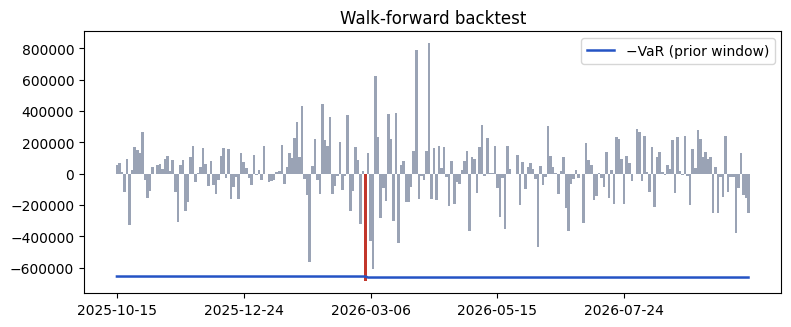

In [20]:
P_all = R_all.values @ e.values
days = min(250, len(P_all) - WINDOW)
rows = []
for t in range(len(P_all) - days, len(P_all)):
    v = -np.sort(P_all[t - WINDOW:t])[k - 1]          # VaR from the prior window only
    rows.append((R_all.index[t], P_all[t], v, P_all[t] < -v))
bt_manual = pd.DataFrame(rows, columns=["date", "pnl", "var", "breach"]).set_index("date")
x, p = int(bt_manual.breach.sum()), 1 - CONF
ll = lambda q: 0.0 if q <= 0 or q >= 1 else (days - x) * math.log(1 - q) + x * math.log(q)
LR = -2 * (ll(p) - ll(x / days)); p_value = chi2.sf(LR, 1)

bt = rk.backtest(e, mkt, rk.RiskConfig("hs", CONF, 1, WINDOW), 250)   # <- what the dashboard calls
check("rolling VaR series", bt_manual["var"], bt["series"]["var"])
check("exception count", x, bt["exceptions"]); check("Kupiec p-value", p_value, bt["p_value"])
zone = "green" if x <= 4 else "yellow" if x <= 9 else "red"
print(f"\n{x} exceptions in {days} days (expected {days * p:.1f}); Kupiec p = {p_value:.2f}; Basel zone: {zone}")
print(bt_manual[bt_manual.breach])

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(bt_manual.index, bt_manual.pnl, color=np.where(bt_manual.breach, "#c2362b", "#9aa3b5"), width=1)
ax.plot(bt_manual.index, -bt_manual["var"], color="#2453c4", lw=1.8, label="−VaR (prior window)")
ax.set_xticks(bt_manual.index[::50]); ax.set_title("Walk-forward backtest"); ax.legend(); plt.show()

## 14. P&L history
The book's P&L since inception on each past close. A trade enters on its trade date, and the last point uses live prices.

✓ P&L history
Last point = P&L since inception = -186,886; max drawdown -1,990,146


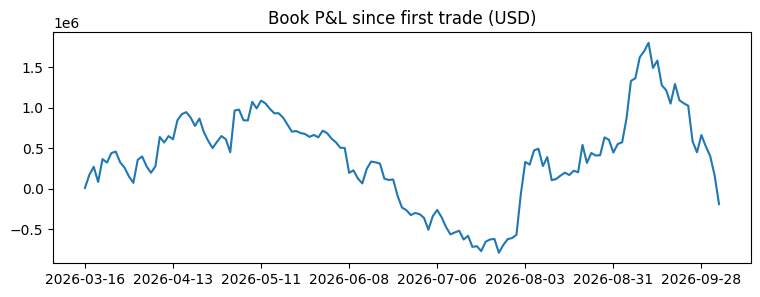

In [21]:
first = book.trade_date.min()
hist_manual = {}
for i, d in enumerate(mkt.hist.index):
    if d >= first:
        u = mkt.rates_at(i)
        hist_manual[d] = sum(usd_value(t, u) for t in book.itertuples() if t.trade_date <= d)
hist_manual[mkt.live_time.strftime("%Y-%m-%d")] = manual.pnl_itd.sum()
hist_manual = pd.Series(hist_manual)
check("P&L history", hist_manual, rk.pnl_history(book, mkt))
dd = (hist_manual - hist_manual.cummax()).min()
print(f"Last point = P&L since inception = {hist_manual.iloc[-1]:,.0f}; max drawdown {dd:,.0f}")
hist_manual.plot(figsize=(9, 3), title="Book P&L since first trade (USD)"); plt.show()

## 15. The dashboard's headline figures
These should match the top row of the dashboard for the same file and price snapshot.

In [22]:
pd.Series({
    "P&L since inception": manual.pnl_itd.sum(),
    "P&L today": manual.pnl_day.sum(),
    f"VaR {CONF:.0%} {HORIZON}d (HS)": var_hs,
    "Expected shortfall (HS)": es_hs,
    "VaR limit used": f"{limit_var / LIMIT:.0%}",
    "Gross notional (USD)": usd_notional.sum(),
}).to_frame("value")

,value
P&L since inception,"-186,886.37"
P&L today,"-354,692.23"
VaR 99% 1d (HS),"662,156.96"
Expected shortfall (HS),"828,405.40"
VaR limit used,66%
Gross notional (USD),"214,008,500.00"
